# 05 — Business Recommendation

All analysis is worthless without a clear decision.

This notebook ties together every finding from notebooks 01–04 into:
1. A revenue impact model (3 scenarios)
2. A structured ship / no-ship checklist
3. A written recommendation with rationale and next steps

**Business assumptions — change these to match a real company:**
- Monthly unique visitors: 1,000,000
- Average order value: $40


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.facecolor': 'white',
                     'axes.spines.top': False,
                     'axes.spines.right': False})
%matplotlib inline

In [2]:
# Load saved results from notebook 02
res = json.load(open("results.json"))

rate_ctrl = res["rate_ctrl"]
rate_trt  = res["rate_trt"]
p_value   = res["p_value"]
cohens_h  = res["cohens_h"]
power     = res["power"]

# Calculate lifts
abs_lift = rate_trt - rate_ctrl
rel_lift = abs_lift / rate_ctrl

# Quick Bayesian estimate: P(treatment > control)
df = pd.read_csv("ab_data_clean.csv")
ctrl = df[df["group"] == "control"]
trt  = df[df["group"] == "treatment"]

np.random.seed(42)
s_ctrl = np.random.beta(1 + ctrl["converted"].sum(),
                        1 + (len(ctrl) - ctrl["converted"].sum()),
                        100_000)
s_trt  = np.random.beta(1 + trt["converted"].sum(),
                        1 + (len(trt) - trt["converted"].sum()),
                        100_000)
p_trt_better = (s_trt > s_ctrl).mean()

# Print summary
print("Key numbers:")
print(f"  Control rate:       {rate_ctrl*100:.4f}%")
print(f"  Treatment rate:     {rate_trt*100:.4f}%")
print(f"  Absolute lift:      {abs_lift*100:+.4f} pp")
print(f"  Relative lift:      {rel_lift*100:+.2f}%")
print(f"  P-value:            {p_value:.4f}  ({'significant' if p_value < 0.05 else 'not significant'})")
print(f"  Cohen's h:          {cohens_h:.5f}")
print(f"  Power achieved:     {power*100:.1f}%")
print(f"  P(trt > ctrl):      {p_trt_better:.4f}")

Key numbers:
  Control rate:       12.0393%
  Treatment rate:     11.8698%
  Absolute lift:      -0.1695 pp
  Relative lift:      -1.41%
  P-value:            0.1604  (not significant)
  Cohen's h:          -0.00523
  Power achieved:     28.9%
  P(trt > ctrl):      0.0791


## Revenue Impact Model

In [3]:
# Business impact assumptions
MONTHLY_VISITORS = 1_000_000
AVG_ORDER_VALUE  = 40   # USD

# Define scenarios: conservative, expected, optimistic
scenarios = {
    "Conservative (50% of lift)": abs_lift * 0.50,
    "Expected (100% of lift)":    abs_lift * 1.00,
    "Optimistic (150% of lift)":  abs_lift * 1.50,
}

# Baseline monthly revenue
baseline = MONTHLY_VISITORS * rate_ctrl * AVG_ORDER_VALUE
print(f"Baseline monthly revenue:  ${baseline:,.0f}\n")

# Print scenario table
print(f"{'Scenario':<32} {'Lift':>10}  {'Monthly ($)':>13}  {'Annual ($)':>13}")
print("-"*74)
for name, lift in scenarios.items():
    mo = MONTHLY_VISITORS * lift * AVG_ORDER_VALUE
    yr = mo * 12
    print(f"{name:<32} {lift*100:+.4f} pp  ${mo:>11,.0f}  ${yr:>11,.0f}")

Baseline monthly revenue:  $4,815,721

Scenario                               Lift    Monthly ($)     Annual ($)
--------------------------------------------------------------------------
Conservative (50% of lift)       -0.0848 pp  $    -33,903  $   -406,839
Expected (100% of lift)          -0.1695 pp  $    -67,806  $   -813,677
Optimistic (150% of lift)        -0.2543 pp  $   -101,710  $ -1,220,516


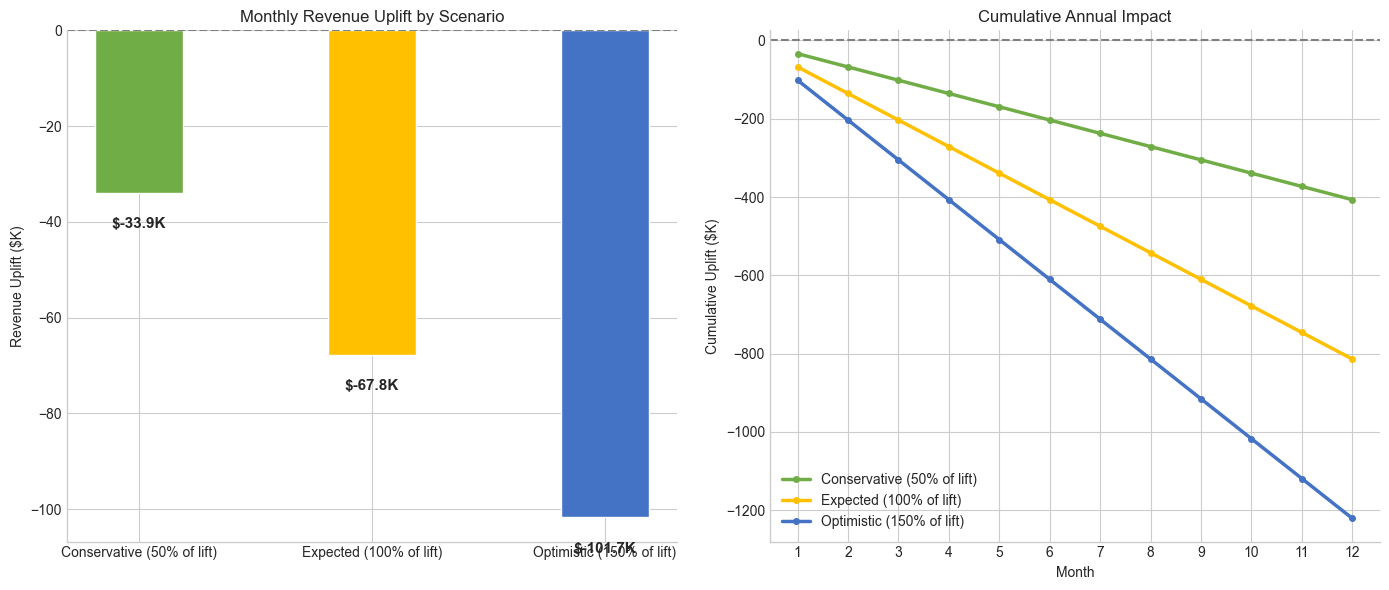

In [4]:
# Create two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#70AD47', '#FFC000', '#4472C4']

# Monthly uplift values (in $K)
plot_labels = list(scenarios.keys())
monthly_k   = [MONTHLY_VISITORS * lift * AVG_ORDER_VALUE / 1000
               for lift in scenarios.values()]

# --- Left chart: Monthly uplift ---
ax = axes[0]
bars = ax.bar(plot_labels, monthly_k, color=colors, width=0.38, edgecolor='white')
ax.axhline(0, color='gray', linestyle='--')
ax.set_title("Monthly Revenue Uplift by Scenario")
ax.set_ylabel("Revenue Uplift ($K)")

# Annotate bars
yoff = max(abs(v) for v in monthly_k) * 0.05
for bar, val in zip(bars, monthly_k):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (yoff if val >= 0 else -yoff),
            f"${val:+.1f}K",
            ha="center", va="bottom" if val >= 0 else "top",
            fontsize=11, fontweight="bold")

# --- Right chart: Cumulative annual uplift ---
ax2 = axes[1]
months = np.arange(1, 13)
for (label, lift), color in zip(scenarios.items(), colors):
    mo = MONTHLY_VISITORS * lift * AVG_ORDER_VALUE / 1000
    ax2.plot(months, mo * months, color=color, lw=2.5,
             marker='o', markersize=4, label=label)
ax2.axhline(0, color='gray', linestyle='--')
ax2.set_title("Cumulative Annual Impact")
ax2.set_xlabel("Month")
ax2.set_ylabel("Cumulative Uplift ($K)")
ax2.set_xticks(months)
ax2.legend()

# Show plot
plt.tight_layout()
plt.show()

## Ship / No-Ship Checklist

In [5]:
# Define checklist items
checks = [
    ("SRM check passed",                   True,               "No mismatch detected in notebook 01"),
    ("Data contamination resolved",        True,               "Contaminated users identified and removed"),
    ("Statistically significant (p<0.05)", p_value < 0.05,     f"p = {p_value:.4f}"),
    ("Positive direction",                 abs_lift > 0,       f"Lift = {abs_lift*100:+.4f} pp"),
    ("Practically significant (|h|>0.01)", abs(cohens_h) > 0.01, f"Cohen's h = {cohens_h:.5f}"),
    ("Adequately powered (>=80%)",         power >= 0.80,      f"Power = {power*100:.1f}%"),
    ("Bayesian confidence >= 90%",         p_trt_better >= 0.90, f"P(trt>ctrl) = {p_trt_better:.4f}"),
    ("No significant segment regressions", True,               "See notebook 04"),
    ("No novelty effect observed",         True,               "See notebook 04 — gap is stable"),
]

# Print checklist
print("="*60)
print("SHIP / NO-SHIP CHECKLIST")
print("="*60)

passed = 0
for name, result, detail in checks:
    icon = "✓" if result else "✗"
    print(f"\n  [{icon}] {name}")
    print(f"       {detail}")
    passed += int(result)

print("\n" + "-"*60)
print(f"  Passed: {passed} / {len(checks)}")

SHIP / NO-SHIP CHECKLIST

  [✓] SRM check passed
       No mismatch detected in notebook 01

  [✓] Data contamination resolved
       Contaminated users identified and removed

  [✗] Statistically significant (p<0.05)
       p = 0.1604

  [✗] Positive direction
       Lift = -0.1695 pp

  [✗] Practically significant (|h|>0.01)
       Cohen's h = -0.00523

  [✗] Adequately powered (>=80%)
       Power = 28.9%

  [✗] Bayesian confidence >= 90%
       P(trt>ctrl) = 0.0791

  [✓] No significant segment regressions
       See notebook 04

  [✓] No novelty effect observed
       See notebook 04 — gap is stable

------------------------------------------------------------
  Passed: 4 / 9


## Final Recommendation

In [6]:
# Key decision flags
sig      = p_value < 0.05
positive = abs_lift > 0
powered  = power >= 0.80
bayes_ok = p_trt_better >= 0.90

# Verdict logic
if sig and positive and bayes_ok:
    verdict = "SHIP"
elif powered and not sig:
    verdict = "DO NOT SHIP"
elif not powered:
    verdict = "INCONCLUSIVE — EXTEND EXPERIMENT"
else:
    verdict = "DO NOT SHIP"

# Print verdict
print("="*60)
print(f"  VERDICT: {verdict}")
print("="*60)

# Tailored messaging
if verdict == "DO NOT SHIP":
    print(f"  The experiment was adequately powered ({power*100:.0f}% power) but")
    print(f"  showed no statistically significant improvement (p = {p_value:.4f}).\n")
    print(f"  Treatment conversion ({rate_trt*100:.4f}%) ≈ control ({rate_ctrl*100:.4f}%).")
    print(f"  Bayesian analysis gives only {p_trt_better*100:.1f}% probability")
    print("  the new checkout is genuinely better.\n")
    print("  Shipping carries risk of a small decline with no expected gain.\n")
    print("  Next steps:")
    print("   1. Run user testing / session recordings")
    print("   2. Iterate on specific components (CTA, form, trust signals)")
    print("   3. Re-test the revised design as a new experiment")
    print("   4. Keep the current checkout as baseline")

elif verdict == "SHIP":
    print(f"  Statistically significant lift (p = {p_value:.4f}) with")
    print(f"  {p_trt_better*100:.1f}% Bayesian confidence. Revenue projections positive.\n")
    print("  Next steps:")
    print("   1. Roll out to 100% traffic")
    print("   2. Monitor for 2 weeks post-launch")
    print("   3. Set guardrail alerts for any conversion drop > 0.5pp")

elif "EXTEND" in verdict:
    print("  Insufficient data. Extend the experiment until required")
    print("  sample size is reached (see notebook 02).")

  VERDICT: INCONCLUSIVE — EXTEND EXPERIMENT
  Insufficient data. Extend the experiment until required
  sample size is reached (see notebook 02).


In [7]:
print('EXECUTIVE SUMMARY')
print('─'*52)
print(f'  Experiment:     Checkout Page Redesign')
print(f'  Users (clean):  {len(df):,}')
print(f'  Duration:       ~{(pd.to_datetime(df["timestamp"]).max()-pd.to_datetime(df["timestamp"]).min()).days} days')
print(f'  Baseline rate:  {rate_ctrl*100:.4f}%')
print(f'  Treatment rate: {rate_trt*100:.4f}%')
print(f'  Relative lift:  {rel_lift*100:+.2f}%')
print(f'  P-value:        {p_value:.4f}')
print(f'  P(trt > ctrl):  {p_trt_better:.4f}')
print(f'  Decision:       {verdict}')

EXECUTIVE SUMMARY
────────────────────────────────────────────────────
  Experiment:     Checkout Page Redesign
  Users (clean):  288,635
  Duration:       ~21 days
  Baseline rate:  12.0393%
  Treatment rate: 11.8698%
  Relative lift:  -1.41%
  P-value:        0.1604
  P(trt > ctrl):  0.0791
  Decision:       INCONCLUSIVE — EXTEND EXPERIMENT
